In [21]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ==========================================
# Load Clean Dataset
# ==========================================

df = pd.read_csv("/content/clean_salary_dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [8]:
print(df.shape)

df.info()

(250000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   job_title         250000 non-null  object 
 1   experience_years  250000 non-null  int64  
 2   education_level   250000 non-null  object 
 3   skills_count      250000 non-null  int64  
 4   industry          250000 non-null  object 
 5   company_size      250000 non-null  object 
 6   location          250000 non-null  object 
 7   remote_work       250000 non-null  object 
 8   certifications    250000 non-null  int64  
 9   salary            250000 non-null  float64
 10  salary_sar        250000 non-null  float64
dtypes: float64(2), int64(3), object(6)
memory usage: 21.0+ MB


In [9]:
X = df.drop("salary", axis=1)

y = df["salary"]

In [10]:
categorical_columns = X.select_dtypes(include="object").columns

numerical_columns = X.select_dtypes(include=np.number).columns

print(categorical_columns)

print()

print(numerical_columns)

Index(['job_title', 'education_level', 'industry', 'company_size', 'location',
       'remote_work'],
      dtype='object')

Index(['experience_years', 'skills_count', 'certifications', 'salary_sar'], dtype='object')


In [11]:
X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

In [12]:
preprocessor = ColumnTransformer(

    transformers=[

        (

            "cat",

            OneHotEncoder(handle_unknown="ignore"),

            categorical_columns

        )

    ],

    remainder="passthrough"

)

In [16]:
linear_model = Pipeline(

    steps=[

        ("preprocessor",preprocessor),

        ("model",LinearRegression())

    ]

)

In [17]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [18]:
linear_model.fit(

    X_train,

    y_train

)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job_title', 'education_level', 'industry', 'company_size', 'location',
       'remote_work'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [19]:
y_pred = linear_model.predict(

    X_test

)

In [22]:
mae = mean_absolute_error(

    y_test,

    y_pred

)

mse = mean_squared_error(

    y_test,

    y_pred

)

rmse = np.sqrt(mse)

r2 = r2_score(

    y_test,

    y_pred

)

print("MAE :",mae)

print("MSE :",mse)

print("RMSE :",rmse)

print("R2 Score :",r2)

MAE : 2.3237564667069817e-05
MSE : 7.733607858884418e-10
RMSE : 2.7809365075248333e-05
R2 Score : 1.0


In [23]:
results = pd.DataFrame({

    "Actual Salary":y_test.values,

    "Predicted Salary":y_pred

})

results.head(20)

,Actual Salary,Predicted Salary
0,164009.0,164008.999994
1,79594.0,79594.000015
2,74090.0,74090.000017
3,177193.0,177192.999977
4,120012.0,120011.999973
5,163369.0,163368.999978
6,111889.0,111888.999956
7,75418.0,75417.999994
8,103067.0,103067.000009
9,190692.0,190692.000011


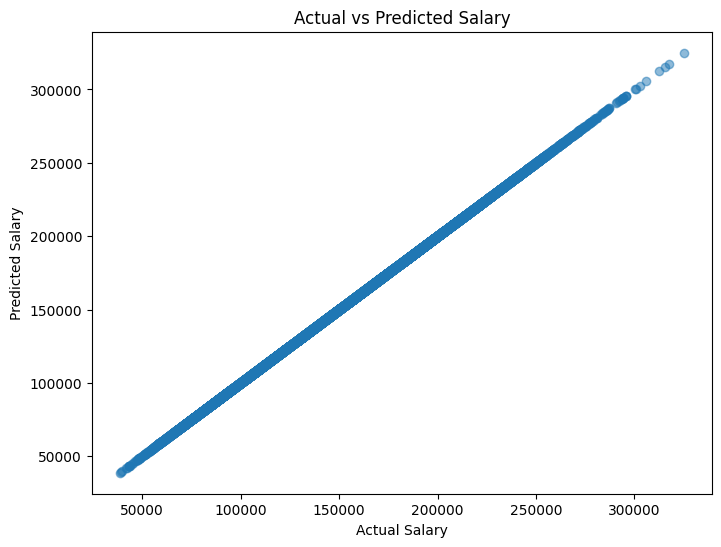

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(

    y_test,

    y_pred,

    alpha=0.5

)

plt.xlabel("Actual Salary")

plt.ylabel("Predicted Salary")

plt.title("Actual vs Predicted Salary")

plt.show()

In [25]:
print(X.columns)

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary_sar'],
      dtype='object')


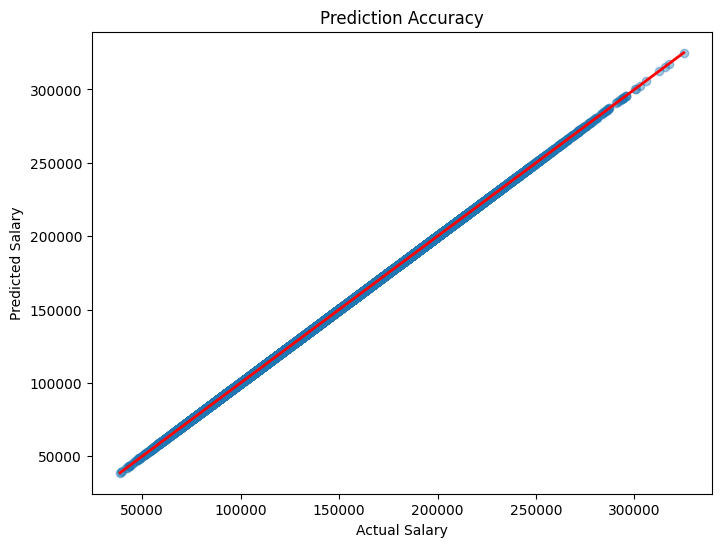

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(

    y_test,

    y_pred,

    alpha=0.4

)

plt.plot(

    [y_test.min(),y_test.max()],

    [y_test.min(),y_test.max()],

    color="red",

    linewidth=2

)

plt.xlabel("Actual Salary")

plt.ylabel("Predicted Salary")

plt.title("Prediction Accuracy")

plt.show()

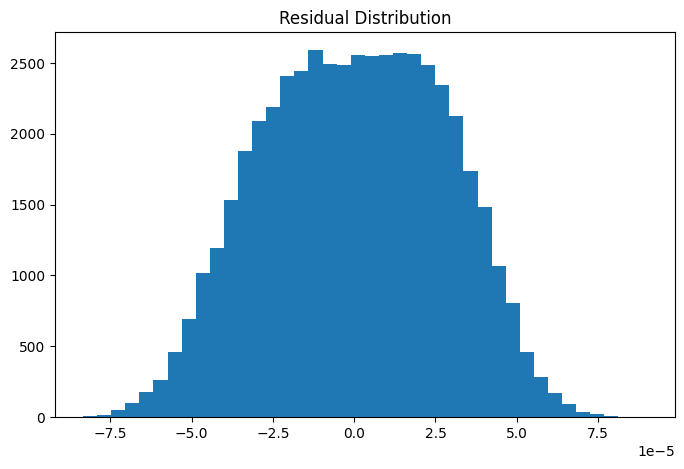

In [27]:
residuals = y_test-y_pred

plt.figure(figsize=(8,5))

plt.hist(

    residuals,

    bins=40

)

plt.title("Residual Distribution")

plt.show()

In [28]:
feature_names = linear_model.named_steps[

    "preprocessor"

].get_feature_names_out()

print("Total Features After Encoding :")

print(len(feature_names))

Total Features After Encoding :
49


In [29]:
from sklearn.model_selection import cross_val_score

In [30]:
scores = cross_val_score(

    linear_model,

    X,

    y,

    cv=5,

    scoring="r2"

)

print(scores)

[1. 1. 1. 1. 1.]


In [31]:
print("Average CV Score :",scores.mean())

Average CV Score : 1.0


In [32]:
joblib.dump(

    linear_model,

    "linear_regression_salary_model.pkl"

)

['linear_regression_salary_model.pkl']

In [33]:
model = joblib.load(

    "linear_regression_salary_model.pkl"

)

In [35]:
sample = pd.DataFrame({

    "job_title":["Data Analyst"],

    "experience_years":[5],

    "education_level":["Bachelor"],

    "skills_count":[12],

    "industry":["Finance"],

    "company_size":["Large"],

    "location":["Saudi Arabia"],

    "remote_work":["Hybrid"],

    "certifications":[2],

    "salary_sar":[5000]

})

prediction = model.predict(sample)

print("Predicted Salary :")

print(prediction[0])

Predicted Salary :
1329.7872671753198


In [36]:
sample["Predicted Salary"] = prediction

sample

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary_sar,Predicted Salary
0,Data Analyst,5,Bachelor,12,Finance,Large,Saudi Arabia,Hybrid,2,5000,1329.787267


How Linear Regression works
Why preprocessing should be inside a Pipeline
How to make predictions on unseen data
How to evaluate regression models using:
MAE
MSE
RMSE
R² Score
Cross-validation
How to save and reload a trained model